# Labour Market: Abel Bernanke and Croushore 7th Edition

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

## Data Imports

U.S. Bureau of Economic Analysis, Real Gross Domestic Product [GDPCA], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/GDPCA, March 17, 2026.

In [2]:
real_gdp = pd.read_csv("../data/GDPCA.csv", header= 0, names= ['date', 'real_gdp_billions'])

real_gdp.head(2)

,date,real_gdp_billions
0,1929-01-01,1191.124
1,1930-01-01,1089.785


U.S. Bureau of Economic Analysis, Gross domestic product (implicit price deflator) [A191RD3A086NBEA], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/A191RD3A086NBEA, March 17, 2026.

In [3]:
gdp_deflator = pd.read_csv("../data/A191RD3A086NBEA.csv", header= 0 , names = ['date', 'deflator'])

gdp_deflator.head(2)

,date,deflator
0,1929-01-01,8.778
1,1930-01-01,8.457


U.S. Bureau of Economic Analysis, Current-Cost Net Stock of Fixed Assets: Private: Nonresidential [K1NTOTL1ES000], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/K1NTOTL1ES000, March 17, 2026.

In [4]:
capital_nominal = pd.read_csv("../data/K1NTOTL1ES000.csv", header= 0, names= ['date', 'capital_millions'])

capital_nominal.head(2)

,date,capital_millions
0,1925-01-01,126977
1,1926-01-01,131537


U.S. Bureau of Labor Statistics, Employment Level [CE16OV], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CE16OV, March 17, 2026.

In [5]:
employment_monthly = pd.read_csv("../data/CE16OV.csv", header= 0, names= ['date', 'employed_thousands'])

employment_monthly.head(2)

,date,employed_thousands
0,1948-01-01,58061.0
1,1948-02-01,58196.0


## Data Cleaning

Converting Stock Capital from Nominal to Real Values

# Abel Bernanke and Croushore 11th Edition

## Data Imports

U.S. Bureau of Labor Statistics, Private Nonfarm Business Sector: Total Factor Productivity [MFPNFBS], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/MFPNFBS, March 18, 2026.

In [6]:
tfp_raw = pd.read_csv("../data/MFPNFBS.csv", header= 0, names= ['date', 'TFP'])

tfp_raw.head(2)

,date,TFP
0,1948-01-01,47.904576
1,1949-01-01,48.482331


## Data Cleaning

In [7]:
## Check Data Types

print(tfp_raw.dtypes, "\n")

## Check for NA Vals 

print(tfp_raw.isna().sum(), "\n")

## Check for duplicates

print(tfp_raw.duplicated().sum(), "\n")

date        str
TFP     float64
dtype: object 

date    0
TFP     0
dtype: int64 

0 



In [8]:
## Convert Year to datetime and contain only the Year

tfp_raw['date'] = pd.to_datetime(tfp_raw['date'], format= "%Y-%m-%d")

tfp_raw.head(2)

,date,TFP
0,1948-01-01,47.904576
1,1949-01-01,48.482331


## Question 1

Calculate and graph the growth rate of total factor productivity since 1960 using FRED series MFPNFBS. 

In [9]:
## Growth Rate is just the percentage change

tfp_raw['growth_rate'] = tfp_raw['TFP'].pct_change()

## Drop the first row because there is no growth rate

tfp_raw.drop(0, inplace= True)

## View

tfp_raw.head()

,date,TFP,growth_rate
1,1949-01-01,48.482331,0.012061
2,1950-01-01,51.509008,0.062428
3,1951-01-01,52.788325,0.024837
4,1952-01-01,53.114730,0.006183
5,1953-01-01,53.964345,0.015996


In [10]:
tfp = tfp_raw[tfp_raw['date'].between("1960-01-01", "2024-01-01")] ## Range of Years Required

tfp.head()

,date,TFP,growth_rate
12,1960-01-01,58.726996,0.004403
13,1961-01-01,59.586871,0.014642
14,1962-01-01,61.680523,0.035136
15,1963-01-01,63.313116,0.026469
16,1964-01-01,65.679019,0.037368


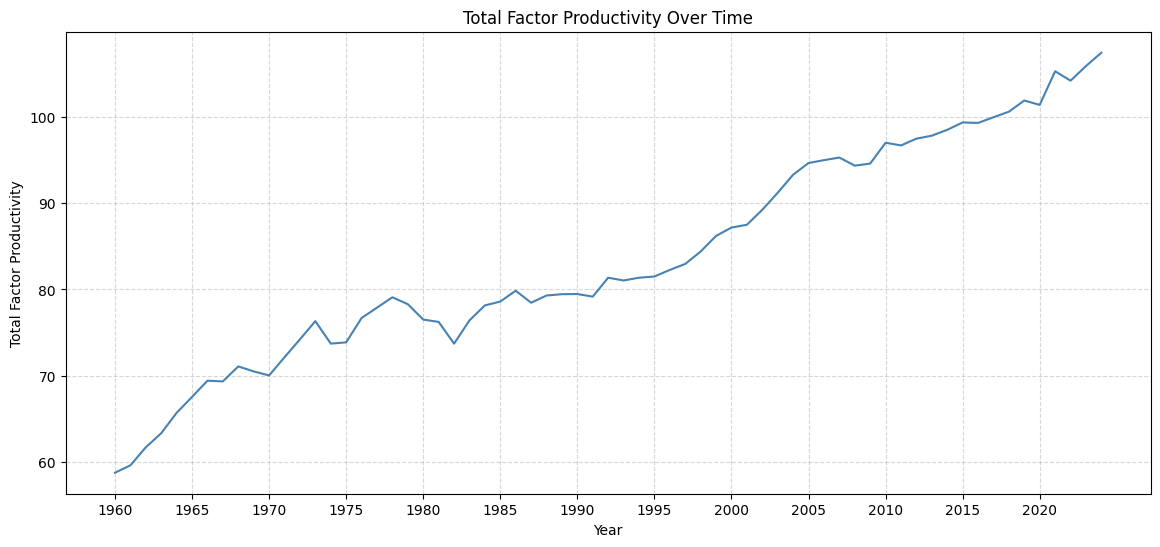

In [11]:
plt.figure(figsize= (14,6))
plt.plot(tfp['date'], tfp['TFP'], color = "steelblue")
plt.xlabel("Year")
plt.ylabel("Total Factor Productivity")
plt.title("Total Factor Productivity Over Time")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.xticks(tfp['date'][::5])
plt.show()

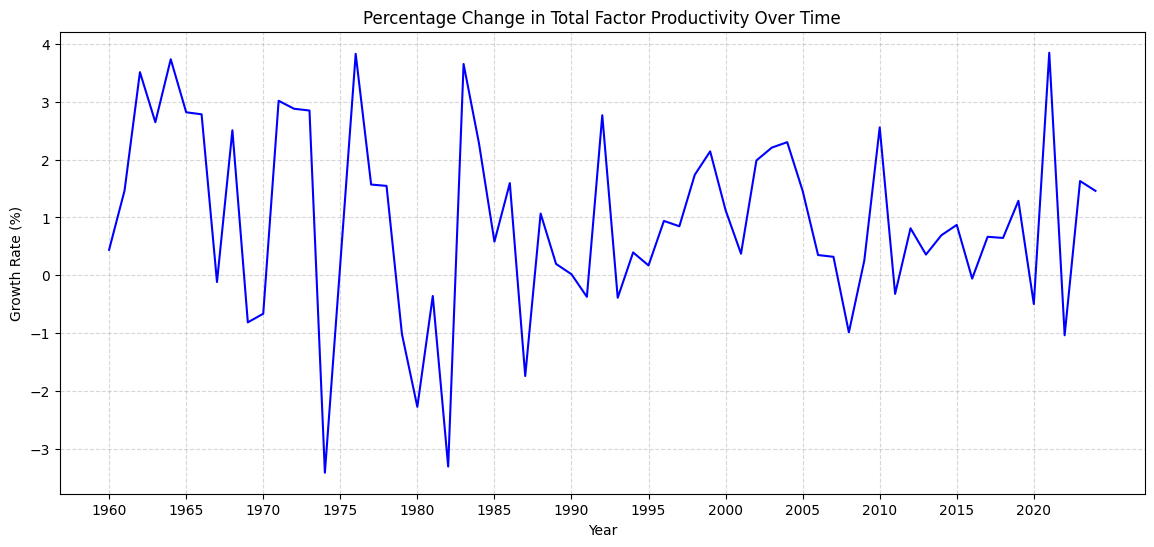

In [12]:
plt.figure(figsize=(14,6))
plt.plot(tfp['date'], tfp['growth_rate']*100, color = 'blue')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.title("Percentage Change in Total Factor Productivity Over Time")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.xticks(tfp['date'][::5])
plt.show()

How do recessions affect the growth rate of productivity?

In [13]:
recession_periods = [
    ("1960-04-01", "1961-02-01"), # Rolling Adjustment Recession
    ("1969-12-01", "1970-11-01"), # Guns and Butter Recession
    ("1973-11-01", "1975-03-01"), # Oil Embargo Recession
    ("1980-01-01", "1980-07-01"), # 1980 Recession (Double-dip part 1)
    ("1981-07-01", "1982-11-01"), # 1981-82 Recession (Double-dip part 2)
    ("1990-07-01", "1991-03-01"), # Gulf War Recession
    ("2001-03-01", "2001-11-01"), # Dot-com Recession
    ("2007-12-01", "2009-06-01"), # The Great Recession
    ("2020-02-01", "2020-04-01")  # COVID-19 Recession
]

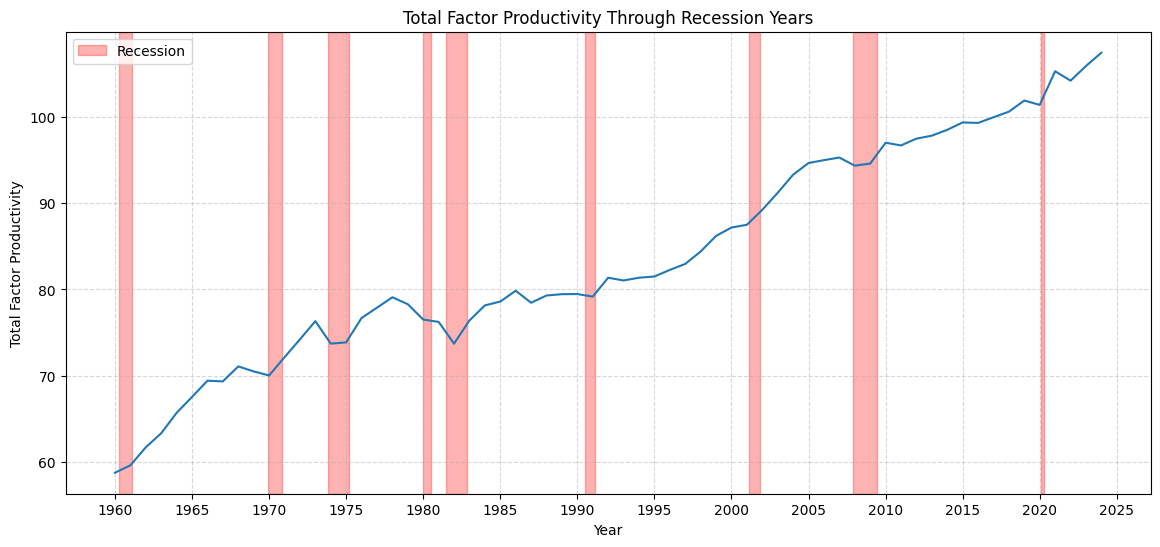

In [14]:
fig, ax = plt.subplots(figsize = (14,6))
ax.plot(tfp['date'], tfp['TFP'])
ax.grid(True, linestyle = "--", alpha = 0.5)

for i , (start, end) in enumerate(recession_periods):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               color = 'red', alpha = 0.3,
               label = "Recession" if i == 0 else "")
    
ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Total Factor Productivity Through Recession Years")
ax.set_ylabel("Total Factor Productivity")
ax.set_xlabel("Year")
ax.legend()

plt.show()


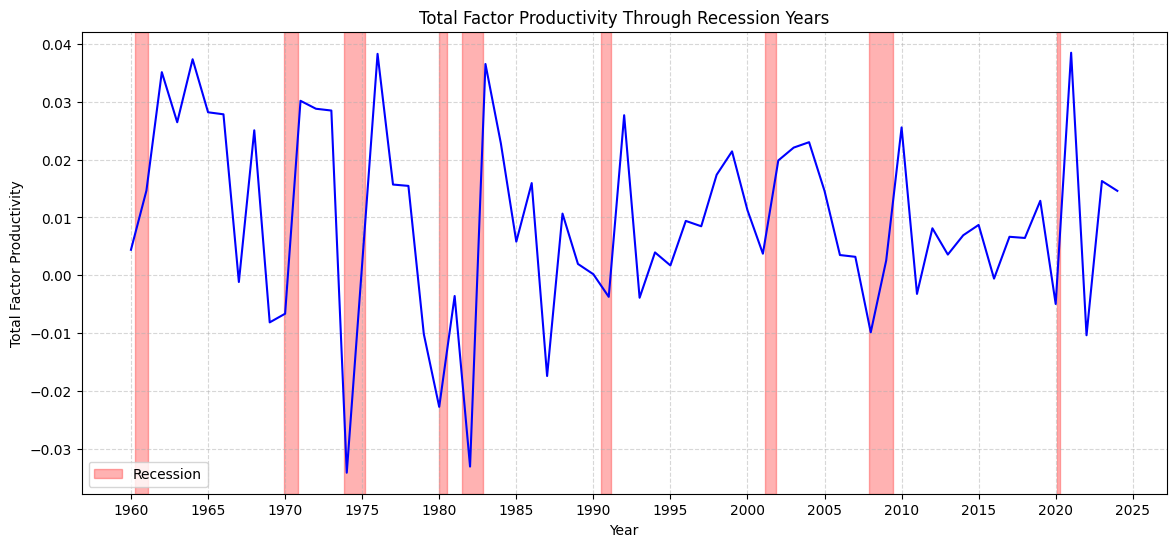

In [15]:
fig, ax = plt.subplots(figsize = (14,6))
ax.plot(tfp['date'], tfp['growth_rate'], color = "blue")
ax.grid(True, linestyle = "--", alpha = 0.5)

for i , (start, end) in enumerate(recession_periods):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               color = 'red', alpha = 0.3,
               label = "Recession" if i == 0 else "")
    
ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Total Factor Productivity Through Recession Years")
ax.set_ylabel("Total Factor Productivity")
ax.set_xlabel("Year")
ax.legend()

plt.show()

How was productivity affected by the oil shocks?

In [16]:
oil_shocks = [
    ("1973-10-01", "1974-03-01"), # 1973 Embargo (Yom Kippur War)
    ("1979-01-01", "1980-12-01"), # 1979 Iranian Revolution / Iran-Iraq War
    ("1990-08-01", "1991-01-01"), # 1990 Gulf War (Invasion of Kuwait)
    ("2007-01-01", "2008-07-01")  # 2000s Surge (Peak prices before Great Recession)
]

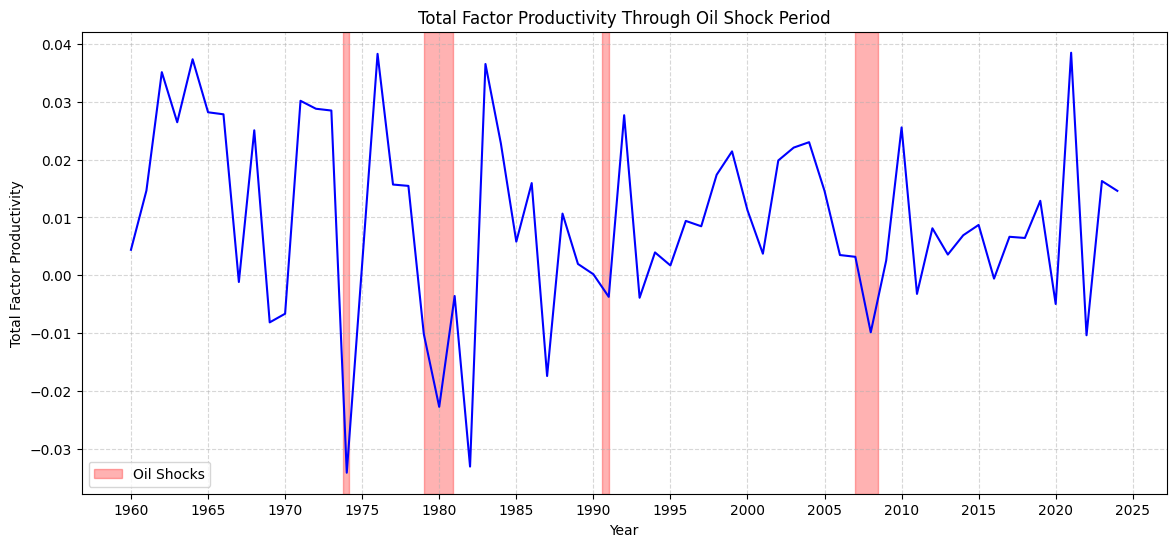

In [18]:
fig, ax = plt.subplots(figsize = (14,6))
ax.plot(tfp['date'], tfp['growth_rate'], color = "blue")
ax.set_xticks(tfp['date'][::5])
ax.grid(True, linestyle = "--", alpha = 0.5)

for i , (start, end) in enumerate(oil_shocks):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               color = 'red', alpha = 0.3,
               label = "Oil Shocks" if i == 0 else "")
    
ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Total Factor Productivity Through Oil Shock Period")
ax.set_ylabel("Total Factor Productivity")
ax.set_xlabel("Year")
ax.legend()

plt.show()